In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.linalg import lu_factor, lu_solve
import scipy
import time
from scipy.interpolate import lagrange

import importlib
from ader_dg_transport.ader_dg_3D import wave_ader

In [110]:
nx = ny = nz = 25
xlim = ylim = zlim = 5
poly_order = 4
c = 1.0
tend = 4.0

cfl = 0.9 * 0.34 * (2 / 3) * 0.5
dt = cfl * (xlim / nx)
nsteps = int(tend / dt) + 1
dt = tend / nsteps

In [111]:
importlib.reload(wave_ader)
solver = wave_ader.WaveAderDG3D(xlim, ylim, zlim, nx, ny, nz, poly_order=poly_order, c=c, dt=dt)
xs = solver.xs[:, :, :, 0]
ys = solver.ys[:, :, :, 0]
zs = solver.zs[:, :, :, 0]

x0 = 2.5
y0 = 2.5
z0 = 2.5
t0 = 0.7
sigma = 0.1149

weights = (solver.weights_3D * solver.dx * solver.dy * solver.dz / 8)[None, None, None, None]
source_mask = np.isclose(solver.xs, x0) & np.isclose(solver.ys, y0) & np.isclose(solver.zs, z0)
point_source_scale = (source_mask / weights) / (source_mask.sum() / 5)

assert source_mask.any()
print(source_mask.sum())


def g(t):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-(t - t0)**2 / (2 * sigma**2))


def g_deriv(t):
    return g(t) * -(t - t0) / (sigma**2)

    
def point_source(x, y, z, t):
    out = np.zeros((x.shape[0], x.shape[1], x.shape[2], 4, x.shape[3], x.shape[4], x.shape[5], x.shape[6]))
    out[:, :, :, 3] = g(t) * point_source_scale
    return out


def h_exact(x, y, z, t):

    r = np.sqrt((x - x0)**2 + (y - y0)**2 + (z - z0)**2)

    return -g_deriv(t - (r / c)) / (4 * np.pi * r * c**2)

5


In [112]:
xr = 3.5
receiver_mask = np.isclose(xs, xr) & np.isclose(ys, y0) & np.isclose(zs, z0)
assert receiver_mask.any()

In [113]:
solver.time = 0.0
solver.state[:] = 0.0

data = [0.0]
times = [0.0]
for _ in range(nsteps):
    solver.time_step(forcing_func=point_source)
    
    data.append((solver.h[receiver_mask]).mean())
    times.append(solver.time)

times = np.array(times)
data = np.array(data)

In [125]:
t_data = np.stack([times, data])
np.save('point_source_data.npy', np.array(t_data))

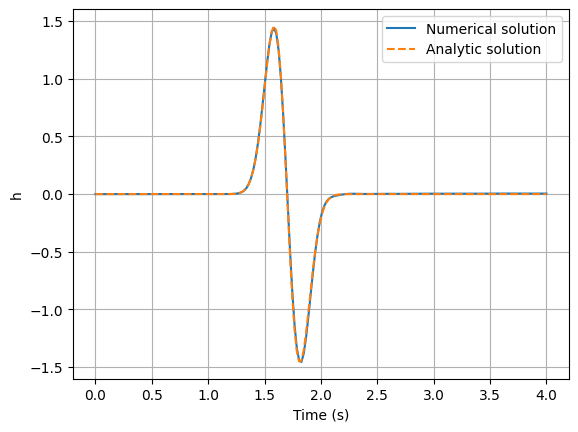

In [124]:
plt.plot(times, data, '-', label='Numerical solution')
plt.plot(times, -h_exact(xr, y0, z0, np.array(times)), '--', label='Analytic solution')
plt.ylabel('h')
plt.xlabel('Time (s)')
plt.legend()
plt.grid()
plt.savefig('point_source_receiver.png')

In [127]:
# t_data = np.load('point_source_data.npy')
# plt.plot(t_data[0], t_data[1], label='Numerical solution')
# plt.plot(t_data[0], -h_exact(3.5, y0, z0, t_data[0]), label='Analytic solution')
# plt.ylabel('h')
# plt.xlabel('Time (s)')
# plt.legend()
# plt.grid()
# plt.savefig('point_source_receiver.png')

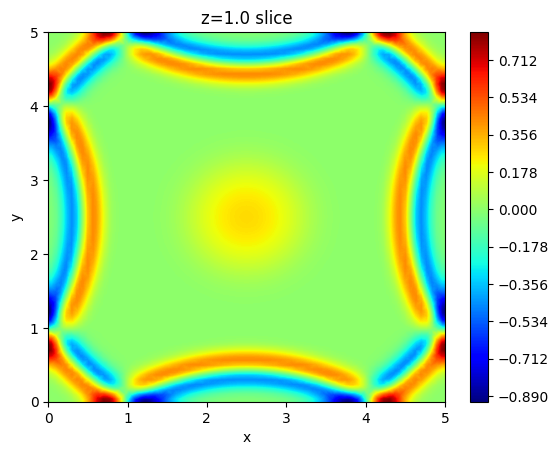

In [128]:
plt.title(f'z={zs[:, :, idx, :, :, 0].min()} slice')
plt.tricontourf(xs[:, :, idx, :, :, 0].ravel(), ys[:, :, idx, :, :, 0].ravel(), solver.h[:, :, idx, :, :, 0].ravel(), levels=1000, cmap='jet')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()

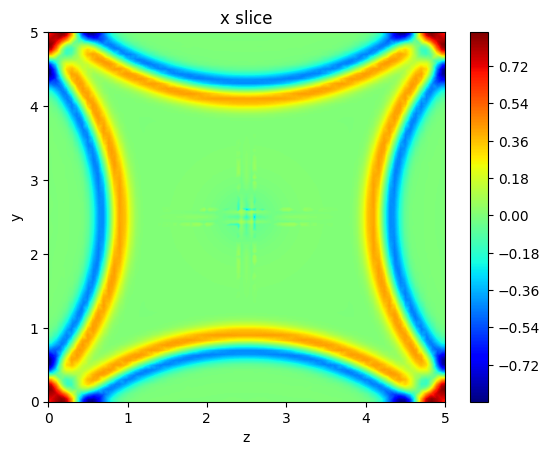

In [129]:
idx = int(nx / 2)
plt.title('x slice')
plt.tricontourf(zs[idx, :, :, 0].ravel(), ys[idx, :, :, 0].ravel(), solver.h[idx, :, :, 0].ravel(), levels=1000, cmap='jet')
plt.xlabel('z')
plt.ylabel('y')
plt.colorbar()

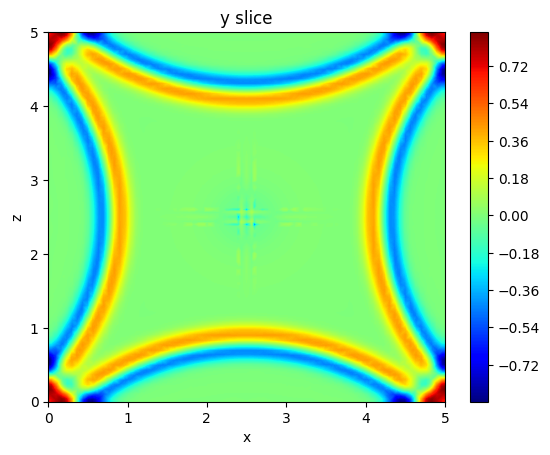

In [130]:
plt.title('y slice')
plt.tricontourf(xs[:, idx, :, :, 0].ravel(), zs[:, idx, :, :, 0].ravel(), solver.h[:, idx, :, :, 0].ravel(), levels=1000, cmap='jet')
plt.xlabel('x')
plt.ylabel('z')
plt.colorbar()